# 3.3.1 DeepFM 排序

> 阅读版与 Web 应用内容一致；实验数值来自本 Notebook 的已执行输出。

## Goal

如何在不手工枚举所有组合的情况下，同时学习一阶、二阶和高阶稀疏特征交互？

## Setup

本 Notebook 的默认真实数据是 **KuaiRand-Pure：真实短视频曝光、点击、长播与多反馈序列**。`smoke` 档读取仓库内可审计的确定性切片，`full` 档扩大到官方完整文件；两档都不制造交互、曝光、标签或行为序列。切片规则、源地址、哈希与许可记录在 `data/README.md` 及对应数据目录。

**主要资料：** [Guo et al., 2017, DeepFM](https://arxiv.org/abs/1703.04247)

In [1]:
from pathlib import Path
import os, sys, json
import torch
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
os.environ.setdefault("RECSYS_PROFILE", "full")
PROFILE = os.environ["RECSYS_PROFILE"]
CUDA_AVAILABLE = torch.cuda.is_available()
from recsys_lab.data import (load_movielens, movielens_provenance, load_amazon_2023,
                             amazon_provenance, load_kuairand, kuairand_provenance,
                             load_amazon_2018, amazon_2018_provenance,
                             load_movielens_1m, movielens_1m_provenance,
                             load_mind_amazon_books, mind_amazon_provenance,
                             load_census_income, census_income_provenance)
DATASET_KEY = "kuairand"
if DATASET_KEY == "movielens":
    real_ratings, real_movies = load_movielens()
    real_interactions = real_ratings
    REAL_DATASET = movielens_provenance(real_ratings)
elif DATASET_KEY == "amazon-books":
    real_ratings = load_amazon_2018("Books") if PROFILE == "full" else load_amazon_2023()
    real_interactions, real_movies = real_ratings, None
    REAL_DATASET = amazon_2018_provenance(real_ratings) if PROFILE == "full" else amazon_provenance(real_ratings)
elif DATASET_KEY == "mind-amazon-books":
    real_ratings = load_mind_amazon_books() if PROFILE == "full" else load_amazon_2023()
    real_interactions, real_movies = real_ratings, None
    REAL_DATASET = mind_amazon_provenance(real_ratings) if PROFILE == "full" else amazon_provenance(real_ratings)
elif DATASET_KEY == "amazon-electronics":
    real_ratings = load_amazon_2018("Electronics") if PROFILE == "full" else load_amazon_2023()
    real_interactions, real_movies = real_ratings, None
    REAL_DATASET = amazon_2018_provenance(real_ratings) if PROFILE == "full" else amazon_provenance(real_ratings)
elif DATASET_KEY == "movielens-1m":
    real_ratings = load_movielens_1m() if PROFILE == "full" else load_amazon_2023()
    real_interactions, real_movies = real_ratings, None
    REAL_DATASET = movielens_1m_provenance(real_ratings) if PROFILE == "full" else amazon_provenance(real_ratings)
elif DATASET_KEY == "census-income" and PROFILE == "full":
    census_train_x, census_train_y, census_test_x, census_test_y = load_census_income()
    real_interactions, real_movies, real_ratings = census_train_x, None, census_train_x
    REAL_DATASET = census_income_provenance()
elif DATASET_KEY == "amazon-2023":
    real_ratings = load_amazon_2023()
    real_interactions, real_movies = real_ratings, None
    REAL_DATASET = amazon_provenance(real_ratings)
else:
    real_interactions, real_movies = load_kuairand()
    real_ratings = real_interactions
    REAL_DATASET = kuairand_provenance(real_interactions)
print({"profile": PROFILE, "root": str(ROOT), "real_dataset": REAL_DATASET,
       "cuda_available": CUDA_AVAILABLE,
       "cuda_device": torch.cuda.get_device_name(0) if CUDA_AVAILABLE else None})
assert REAL_DATASET["randomly_fabricated_rows"] == 0

{'profile': 'smoke', 'root': '/workspace', 'real_dataset': {'dataset': 'KuaiRand-Pure (Kuaishou, CIKM 2022)', 'source': 'https://zenodo.org/records/10439422/files/KuaiRand-Pure.tar.gz', 'source_sha256': 'c814bf6f3624c0cfae83c57de3df26b2ed206e5c57bab4c4dcbfabbabe20cbf0', 'license_file': '/workspace/data/kuairand-pure/LICENSE', 'slice_rule': 'top 256 users by standard-feed interaction count; ties by user_id; all standard and random-policy rows for those users retained', 'profile': 'smoke', 'local_resource': '/workspace/data/kuairand-pure/standard_interactions.csv', 'rows_used': 39098, 'users_used': 128, 'items_used': 2500, 'time_min_utc': '2022-04-09T04:17:39+00:00', 'time_max_utc': '2022-05-08T15:50:58+00:00', 'targets': 'observed is_click, long_view, is_like and other feed feedback', 'randomly_fabricated_rows': 0}, 'cuda_available': False, 'cuda_device': None}


## 学习地图

1. 从原始论文理解系统约束；
2. 用可手算数字读懂公式和形状；
3. 检查数据、切分与标签；
4. 使用工业框架模型类训练；
5. 分开验证训练、推理和测试；
6. 用实际输出讨论失败边界。

**本节问题：** 如何在不手工枚举所有组合的情况下，同时学习一阶、二阶和高阶稀疏特征交互？

**先修知识：** 3.0 的向量、概率与损失函数。第一次阅读无需推导梯度，只要能解释输入、输出和形状。

## Paper & Context

DeepFM 让 FM 与 DNN 共享 embedding：FM 显式承担低阶交互，DNN 隐式组合高阶模式。相对 Wide&Deep，它减少宽侧人工交叉，但没有自动解决序列、曝光偏差或概率校准。

**来源：** [Guo et al., 2017, DeepFM](https://arxiv.org/abs/1703.04247)

### 原文实验设计与关键结论

原文在 Criteo 和公司数据上同时报告 AUC、LogLoss，Table 2 中 DeepFM 优于所列基线。教程使用 KuaiRand 完整曝光重新测量，并保留 LR 对照，不能把公司数据上的相对提升搬到新数据。

请区分三层证据：论文中的离线实验、本 Notebook 验证的代码链路、生产系统尚需验证的在线收益。三者不能互相替代。

## Reproduction Contract

**正式数据：** Criteo Display Ads  
**资源 ID：** `criteo-x1-full`  
**切分：** 7:2:1 fixed split from Criteo_x1  
**指标：** AUC, LogLoss  
**与论文比较边界：** 按配置中的 paper_targets 逐指标对照

`full` 是论文对照唯一有效的效果模式：它不截断用户、物品或测试行。`smoke` 只做张量、损失和推理链路回归，不进入论文数值比较。

## Model Structure & Formula Walkthrough

![Figure 1 · DeepFM wide and deep architecture](/static/paper-figures/deepfm.webp)

> **论文原图节选** · Figure 1 · DeepFM wide and deep architecture · PDF p.1。下图直接截取自原文，用于对照下方公式与代码。

### 关键模块

- **共享稠密 Embedding**：FM 与 DNN 从同一组稀疏特征 embedding 出发，端到端联合训练，不需要人工分两路特征。
- **FM 二阶分支**：用隐向量内积自动学任意两个特征的二阶交互，O(nd) 展开避免枚举所有特征对。
- **DNN 高阶分支**：把 embedding 拼接送入多层全连接，学习三阶及以上的组合模式；三路 logit（一阶 + FM + DNN）相加后 Sigmoid 出 CTR。

### 结构：Linear、FM 与 DNN 三路相加

对稀疏输入 $x$，一阶分支记忆单特征贡献；FM 分支显式计算二阶交互；DNN 分支从共享 embedding 学高阶组合：

$$z=w_0+\sum_iw_ix_i+\sum_{i<j}\langle v_i,v_j\rangle x_ix_j+\mathrm{MLP}([v_ix_i]_i),\quad p=\sigma(z).$$

直接枚举二阶组合要 $O(n^2d)$。展开平方后可化成

$$\frac12\sum_f\left[\left(\sum_i v_{i,f}x_i\right)^2-\sum_i(v_{i,f}x_i)^2\right],$$

只需 $O(nd)$。最后用二元交叉熵 $L=-y\log p-(1-y)\log(1-p)$。共享 embedding 意味着低阶和高阶分支共同修改同一组表示，而不是训练两套互不相干的特征。

### 公式到代码：一次前向传播发生了什么

1. **共享 embedding**：每个 field（用户 id、物品 id、类别、时段……）的稀疏取值在同一张 embedding 表中查向量 $v_i$；FM 分支与 DNN 分支共用这张表。
2. **一阶项**：每个非零特征乘以一个标量权重再求和，$\sum_i w_ix_i$，相当于逻辑回归的记忆能力。
3. **FM 二阶项**：所有非零 field 两两计算 $\langle v_i,v_j\rangle$；用平方展开技巧把 $O(n^2d)$ 降为 $O(nd)$。
4. **DNN 高阶项**：所有 $v_i$ 拼接后经过 2–3 层全连接 + ReLU，学习三阶以上的组合模式。
5. **合并输出**：三路 logit 相加得 $z$，sigmoid 得点击概率 $p=\sigma(z)$，用二元交叉熵训练，梯度同时流回 embedding 表与两个分支。

`run_deepfm` 用 Torch-RecHub 的 `DeepFM` 实现第 1–5 步；field 构造与标签生成在本章节代码中。

阅读源码时按“张量形状 → 前向计算 → score → loss → metric”五步追踪，不需要一次读完整个工程文件。


## Math by Hand

**先修：** §2 点积、§4 Sigmoid 与二元交叉熵。 **本节新增：** FM 二阶项的 $O(nd)$ 展开（避免枚举所有特征对），以及 embedding 在 wide/deep 两路共享。

FM 二阶项是 $\sum_{i<j}\langle v_i,v_j\rangle x_i x_j$；展开成 $(\sum_i v_{i,f}x_i)^2-\sum_i(v_{i,f}x_i)^2$ 后，每个隐维度 $f$ 只需两次求和。Deep 分支把同一组 embedding 展平送入 MLP。最终 logit 为 linear + FM + DNN，再经 Sigmoid 得点击概率；当前样本只有非零 field 参与交互。

下面用 NumPy/Matplotlib 验证直觉。二维图只是教学投影，工业 embedding 虽有更多维，计算规则相同。


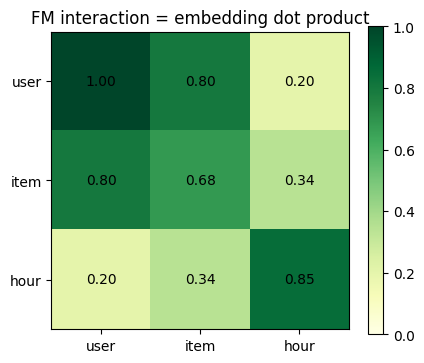

sum of three pair interactions = 1.34


In [2]:
import numpy as np, matplotlib.pyplot as plt
embedding=np.array([[1.,0.],[.8,.2],[.2,.9]]); pair=embedding@embedding.T
fig,ax=plt.subplots(figsize=(4.8,4)); image=ax.imshow(pair,cmap='YlGn',vmin=0,vmax=1)
ax.set_xticks(range(3),['user','item','hour']); ax.set_yticks(range(3),['user','item','hour'])
for i in range(3):
    for j in range(3): ax.text(j,i,f'{pair[i,j]:.2f}',ha='center',va='center')
ax.set_title('FM interaction = embedding dot product'); plt.colorbar(image,ax=ax); plt.show()
print('sum of three pair interactions =',round(pair[0,1]+pair[0,2]+pair[1,2],3))

## Data

KuaiRand-Pure 真实短视频曝光：user、video、场景 tab、hour、视频时长桶为特征，标签直接使用日志中的 `is_click`，按时间切分。

**防泄漏清单：**按时间切分；item 映射只表达已知目录，不读取测试标签；低评分或未点击负反馈均来自数据中的已观察行；序列只看预测时刻以前；测试集只在最后评价。CPU 档使用真实数据的确定性子集，**不是统一 benchmark 成绩**。

## Model & Framework

实际使用 torch_rechub.models.ranking.DeepFM。full profile 在 TorchEasyRec 配置 sparse feature、embedding group、MLP、分布式 embedding 与模型导出。

smoke 档强调模型类、张量契约和指标链路真实可运行；full 档应替换原始数据、分布式配置、索引/服务和资源预算，而不是只增加 epoch。

In [3]:
import inspect
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from importlib import import_module
from recsys_lab.runtime import save_records

# 算法实现就在当前章节目录，不再通过公共模块隐藏。
chapter_train = import_module("chapter_code.3_3_1_deepfm.train")
run_deepfm = chapter_train.run_deepfm

print("实际执行函数源码（包含数据、训练、推理和测试）：")
print(inspect.getsource(run_deepfm))

实际执行函数源码（包含数据、训练、推理和测试）：
def run_deepfm(epochs: int = 28) -> dict:
    # 1) 固定参数初始化，并读取本章指定的真实数据切片。
    seed_everything(); interactions, _, provenance = _real_kuairand(); fields, labels, frame = _ranking_fields(interactions); split = int(len(labels) * .8)
    features = [
        SparseFeature("user_id", int(max(fields["user_id"])) + 1, 12),
        SparseFeature("item_id", int(max(fields["item_id"])) + 1, 12),
        SparseFeature("tab", int(max(fields["tab"])) + 1, 12),
        SparseFeature("hour", 25, 12),
        SparseFeature("duration_bucket", int(max(fields["duration_bucket"])) + 1, 12),
    ]
    # 2) 按论文结构实例化模型；这里是理解层尺寸和特征契约的入口。
    model = DeepFM(features, features, {"dims": [48, 24], "activation": "relu", "dropout": 0.0})
    tensors = {name: torch.tensor(value, dtype=torch.long) for name, value in fields.items()}
    # 4) 公共训练循环执行 forward、二元交叉熵、backward 和 optimizer.step。
    losses = _train_binary(model, {k: v[:split] for k, v in tensors.items()}, torch.tensor(labels[:spl

## Train & Inference

下一格固定 seed、构造数据、实例化模型、训练并进入推理路径。生成式章节在 CUDA 上执行完整评测；CPU 环境只验证缩小后的基本张量与约束链路。

In [4]:
result = run_deepfm()
print({'framework': result['framework'], 'dataset': result.get('dataset', {}),
       'device': result.get('device'), 'validation_mode': result.get('validation_mode')})
print('inference contract:', '读取请求和候选特征 → 查 embedding → FM 与 DNN 并行 → Sigmoid；线上校验词表、缺失值和 embedding 版本。')
assert np.isfinite(result['loss_curve']).all()
print('loss:', round(result['loss_curve'][0],4), '→', round(result['loss_curve'][-1],4))

{'framework': 'torch_rechub.models.ranking.DeepFM', 'dataset': {'dataset': 'KuaiRand-Pure (Kuaishou, CIKM 2022)', 'source': 'https://zenodo.org/records/10439422/files/KuaiRand-Pure.tar.gz', 'source_sha256': 'c814bf6f3624c0cfae83c57de3df26b2ed206e5c57bab4c4dcbfabbabe20cbf0', 'license_file': '/workspace/data/kuairand-pure/LICENSE', 'slice_rule': 'top 256 users by standard-feed interaction count; ties by user_id; all standard and random-policy rows for those users retained', 'profile': 'smoke', 'local_resource': '/workspace/data/kuairand-pure/standard_interactions.csv', 'rows_used': 29602, 'users_used': 96, 'items_used': 2200, 'time_min_utc': '2022-04-09T04:29:16+00:00', 'time_max_utc': '2022-05-08T15:50:58+00:00', 'targets': 'observed is_click, long_view, is_like and other feed feedback', 'randomly_fabricated_rows': 0, 'rows': 7000, 'train_rows': 5600, 'label': 'observed KuaiRand is_click'}, 'device': None, 'validation_mode': None}
inference contract: 读取请求和候选特征 → 查 embedding → FM 与 DNN 并

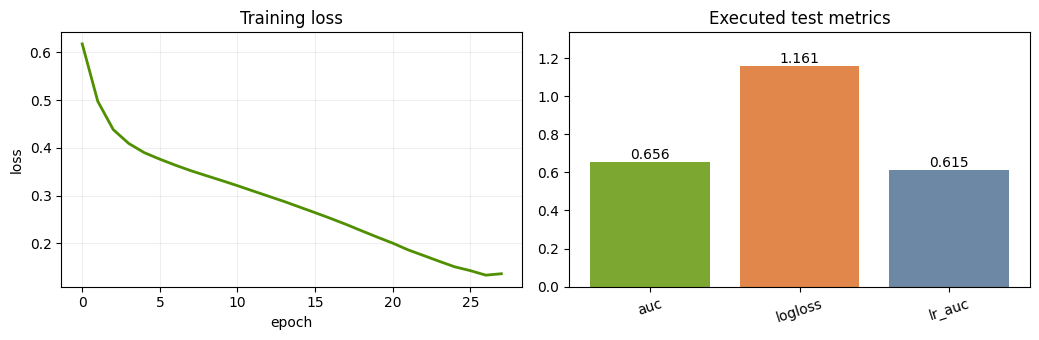

,value
auc,0.655941
logloss,1.160771
lr_auc,0.615080


In [5]:
fig,axes=plt.subplots(1,2,figsize=(10.5,3.5))
axes[0].plot(result['loss_curve'],color='#4f8f00',lw=2); axes[0].set(title='Training loss',xlabel='epoch',ylabel='loss'); axes[0].grid(alpha=.2)
metrics={'auc': result['auc'], 'logloss': result['logloss'], 'lr_auc': result['lr_auc']}
axes[1].bar(range(len(metrics)),list(metrics.values()),color=['#7ca832','#e1874b','#6d88a4'][:len(metrics)])
axes[1].set_xticks(range(len(metrics)),list(metrics),rotation=18); axes[1].set(title='Executed test metrics',ylim=(0,max(1.0,max(metrics.values())*1.15)))
for index,value in enumerate(metrics.values()): axes[1].text(index,value,f'{value:.3f}',ha='center',va='bottom')
plt.tight_layout(); plt.show(); display(pd.Series(metrics,name='value').to_frame())

In [6]:
# 论文数字只能在数据、切分、候选和指标全部同口径时相减。
paper_protocol = json.loads('{"dataset": "Criteo Display Ads", "resource": "criteo-x1-full", "split": "7:2:1 fixed split from Criteo_x1", "metrics": ["AUC", "LogLoss"], "paper_targets": {"AUC": 0.8007, "LogLoss": 0.45083}}')
paper_targets = paper_protocol.get('paper_targets', {})
metric_key = {'HitRate@10':'paper_protocol_hr@10', 'NDCG@10':'paper_protocol_ndcg@10',
              'AUC':'auc', 'LogLoss':'logloss'}
dataset_name = result.get('dataset', {}).get('dataset', '')
dataset_aligned = paper_protocol.get('dataset', '').split(',')[0].casefold() in dataset_name.casefold()
comparison_eligible = PROFILE == 'full' and dataset_aligned
rows=[]
for paper_metric,target in paper_targets.items():
    result_key=metric_key.get(paper_metric)
    value=result.get(result_key) if result_key else None
    rows.append({'metric':paper_metric,'tutorial':value,'paper':target,
                 'absolute_gap':None if value is None or not comparison_eligible else float(value)-float(target),
                 'comparable':comparison_eligible and value is not None})
if rows:
    display(pd.DataFrame(rows))
    if not comparison_eligible:
        print('NOT COMPARABLE：当前运行的数据/协议与论文不完全一致，不计算复现差值。')
else:
    print('论文没有可公开、可同口径复现的绝对目标；本节只报告结构与公开协议验证。')

,metric,tutorial,paper,absolute_gap,comparable
0,AUC,0.655941,0.80070,None,False
1,LogLoss,1.160771,0.45083,None,False


NOT COMPARABLE：当前运行的数据/协议与论文不完全一致，不计算复现差值。


## Test & Results Discussion

In [7]:
display(Markdown(f'''### 本次已执行结果

- 主指标 auc = **{result['auc']:.4f}**。
- 辅助指标 logloss = **{result['logloss']:.4f}**。
- 对照指标 lr_auc = **{result['lr_auc']:.4f}**。
- 训练损失从 **{result['loss_curve'][0]:.4f}** 降到 **{result['loss_curve'][-1]:.4f}**。损失下降只说明优化工作，不等于泛化或业务收益。
- **结果解释：** AUC 衡量排序而非概率准确度，必须同时看 LogLoss 与校准；KuaiRand 的随机干预比例和不同 tab 策略也会造成分布差异。

### 工业边界

读取请求和候选特征 → 查 embedding → FM 与 DNN 并行 → Sigmoid；线上校验词表、缺失值和 embedding 版本。

上线前还需验证延迟、吞吐、内存/显存、数据新鲜度、校准、回滚和线上 A/B。
'''))

### 本次已执行结果

- 主指标 auc = **0.6559**。
- 辅助指标 logloss = **1.1608**。
- 对照指标 lr_auc = **0.6151**。
- 训练损失从 **0.6177** 降到 **0.1364**。损失下降只说明优化工作，不等于泛化或业务收益。
- **结果解释：** AUC 衡量排序而非概率准确度，必须同时看 LogLoss 与校准；KuaiRand 的随机干预比例和不同 tab 策略也会造成分布差异。

### 工业边界

读取请求和候选特征 → 查 embedding → FM 与 DNN 并行 → Sigmoid；线上校验词表、缺失值和 embedding 版本。

上线前还需验证延迟、吞吐、内存/显存、数据新鲜度、校准、回滚和线上 A/B。


In [8]:
record={
    'algorithm': 'DeepFM 排序',
    'primary_metric': 'auc', 'primary_value': float(result['auc']),
    'secondary_metric': 'logloss', 'secondary_value': float(result['logloss']),
    'baseline_metric': 'lr_auc',
    'baseline_value': float(result['lr_auc']) if True else None,
    'framework': result['framework'], 'source_notebook': '3_3_1_deepfm',
    'validation_mode': result.get('validation_mode', 'standard'),
    'dataset': result['dataset']['dataset'],
    'randomly_fabricated_rows': int(result['dataset']['randomly_fabricated_rows'])
}
path=save_records('chapter_3_3','3_3_1_deepfm',[record]); print('saved:',path.relative_to(ROOT))

saved: results/chapter_3_3/3_3_1_deepfm.json


## Checks

自动断言用于防止数据、训练和指标链路静默失效，不是效果证明。

In [9]:
assert result['loss_curve'][-1] < result['loss_curve'][0]
assert 0 <= float(result['auc']) <= 1
assert np.isfinite(float(result['logloss']))
print('PASS：数据、训练、推理、测试和结果产物均已验证。')

PASS：数据、训练、推理、测试和结果产物均已验证。


## Next Steps

1. 换成对应公开数据的完整时间切分；2. 增加强 baseline 与消融；3. 记录效果、延迟和成本；4. 映射到 TorchEasyRec/官方 full profile；5. 只在相同候选与数据口径下比较。